In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

BASE_DIR = Path.cwd().parent

RAW_DATA = BASE_DIR / "data" / "raw"

fund_master = pd.read_csv(RAW_DATA / "01_fund_master.csv")
nav = pd.read_csv(RAW_DATA / "02_nav_history.csv")
aum = pd.read_csv(RAW_DATA / "03_aum_by_fund_house.csv")
sip = pd.read_csv(RAW_DATA / "04_monthly_sip_inflows.csv")
category = pd.read_csv(RAW_DATA / "05_category_inflows.csv")
folio = pd.read_csv(RAW_DATA / "06_industry_folio_count.csv")
transactions = pd.read_csv(RAW_DATA / "08_investor_transactions.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [4]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [7]:
nav.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [8]:
nav["date"] = pd.to_datetime(nav["date"])

In [10]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [11]:
sample = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]]

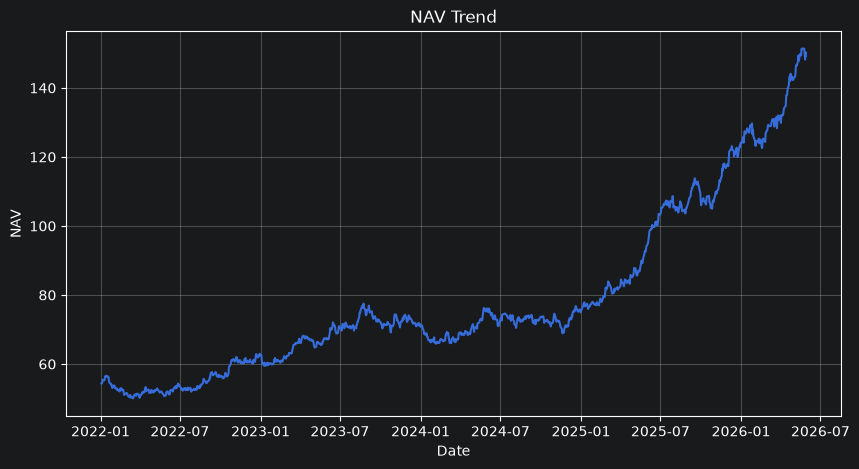

In [12]:
plt.figure(figsize=(10,5))
plt.plot(sample["date"], sample["nav"])
plt.title("NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()

In [13]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [14]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [15]:
nav.shape

(46000, 3)

In [16]:
nav.sort_values("nav", ascending=False).head()

,amfi_code,date,nav
27599,120844,2026-05-29,4268.5497
27598,120844,2026-05-28,4266.9021
27597,120844,2026-05-27,4264.9256
27596,120844,2026-05-26,4262.3302
27594,120844,2026-05-22,4260.3220


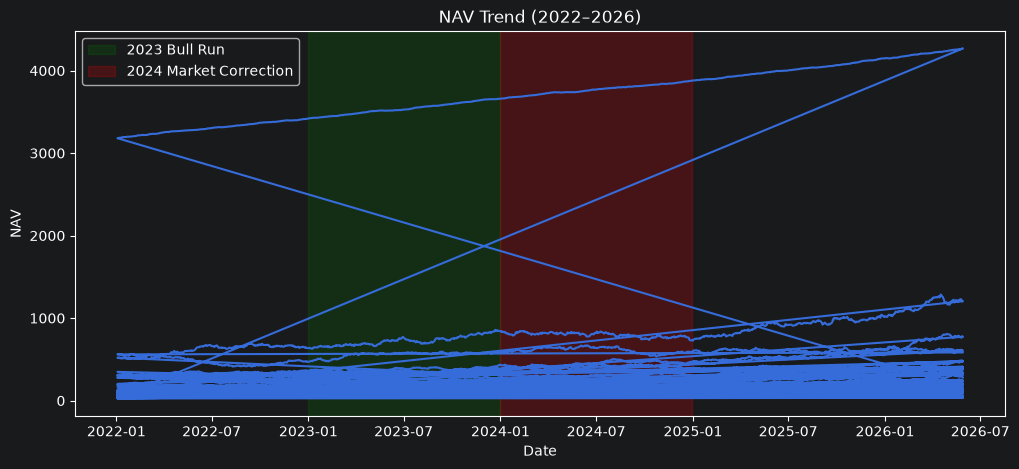

In [17]:
plt.figure(figsize=(12,5))

plt.plot(nav["date"], nav["nav"])

plt.axvspan(pd.Timestamp("2023-01-01"),
            pd.Timestamp("2023-12-31"),
            color="green",
            alpha=0.2,
            label="2023 Bull Run")

plt.axvspan(pd.Timestamp("2024-01-01"),
            pd.Timestamp("2024-12-31"),
            color="red",
            alpha=0.2,
            label="2024 Market Correction")

plt.title("NAV Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()

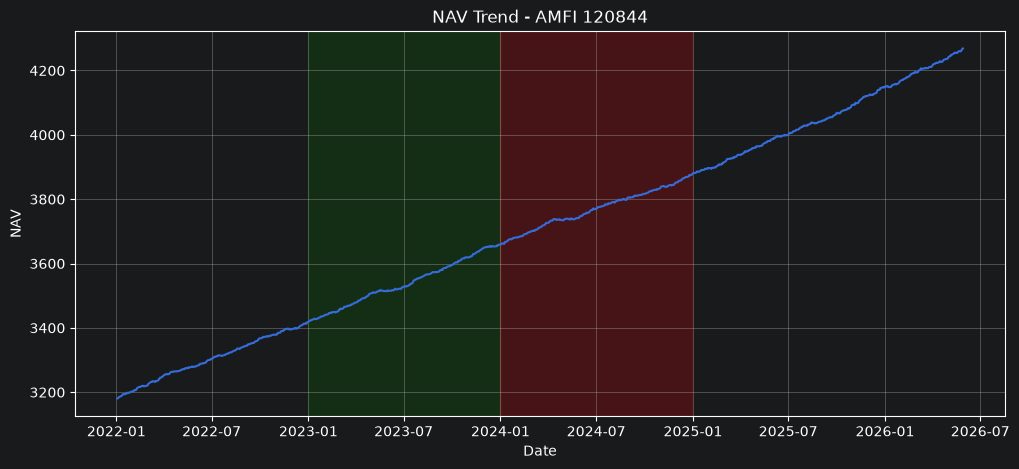

In [18]:
sample = nav[nav["amfi_code"] == 120844]

plt.figure(figsize=(12,5))
plt.plot(sample["date"], sample["nav"])

plt.axvspan(pd.Timestamp("2023-01-01"),
            pd.Timestamp("2023-12-31"),
            color="green",
            alpha=0.2)

plt.axvspan(pd.Timestamp("2024-01-01"),
            pd.Timestamp("2024-12-31"),
            color="red",
            alpha=0.2)

plt.title("NAV Trend - AMFI 120844")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()

In [19]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [20]:
aum["date"] = pd.to_datetime(aum["date"])

In [21]:
latest_aum = aum[aum["date"] == aum["date"].max()]
latest_aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168


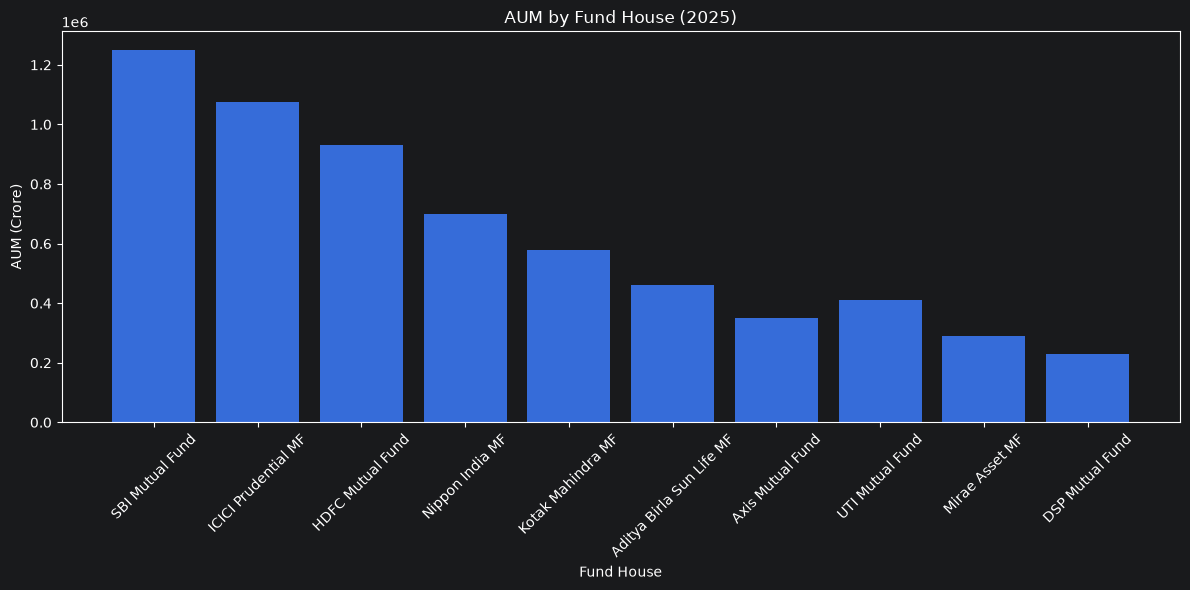

In [22]:
plt.figure(figsize=(12,6))

plt.bar(latest_aum["fund_house"], latest_aum["aum_crore"])

plt.title("AUM by Fund House (2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

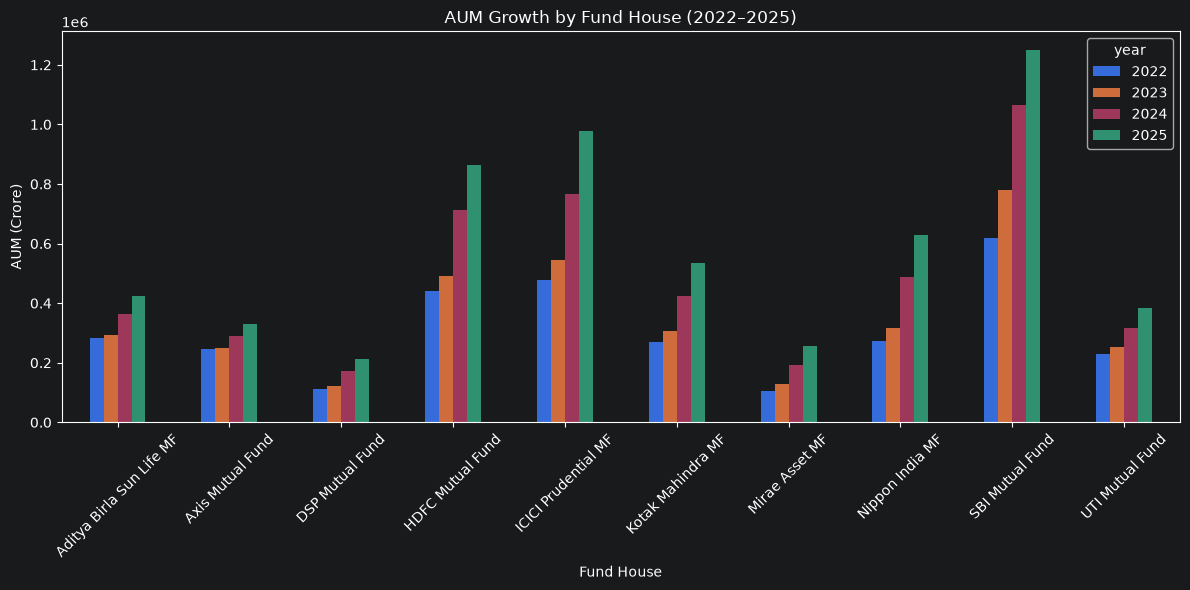

In [26]:
aum["year"] = aum["date"].dt.year

pivot_aum = aum.pivot_table(
    index="fund_house",
    columns="year",
    values="aum_crore",
    aggfunc="mean"
)

pivot_aum.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [27]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [28]:
sip["month"] = pd.to_datetime(sip["month"])

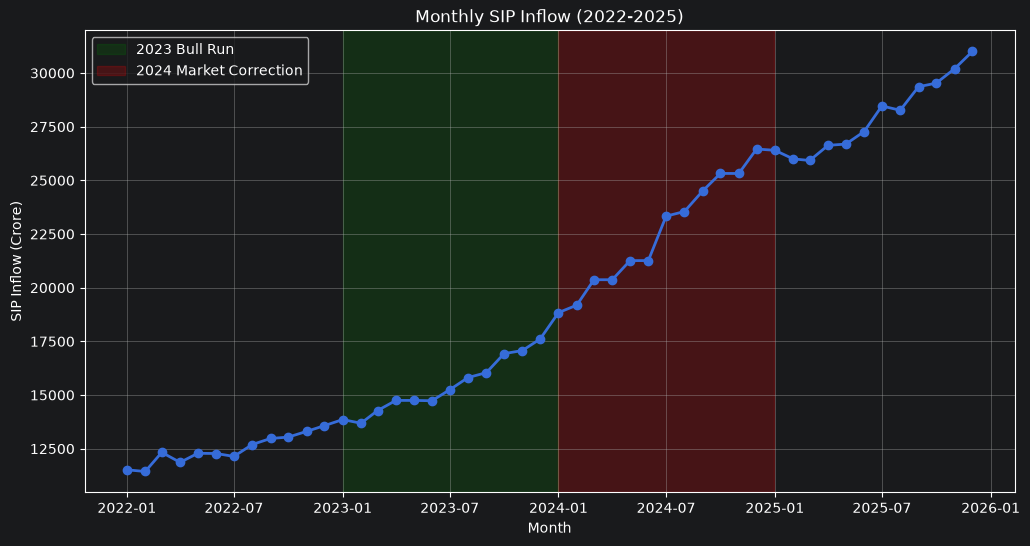

In [29]:
plt.figure(figsize=(12,6))

plt.plot(sip["month"], sip["sip_inflow_crore"],
         marker="o", linewidth=2)

plt.axvspan(pd.Timestamp("2023-01-01"),
            pd.Timestamp("2023-12-31"),
            color="green",
            alpha=0.2,
            label="2023 Bull Run")

plt.axvspan(pd.Timestamp("2024-01-01"),
            pd.Timestamp("2024-12-31"),
            color="red",
            alpha=0.2,
            label="2024 Market Correction")

plt.title("Monthly SIP Inflow (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [31]:
category["month"] = pd.to_datetime(category["month"])
category["month"] = category["month"].dt.strftime("%Y-%m")

In [32]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


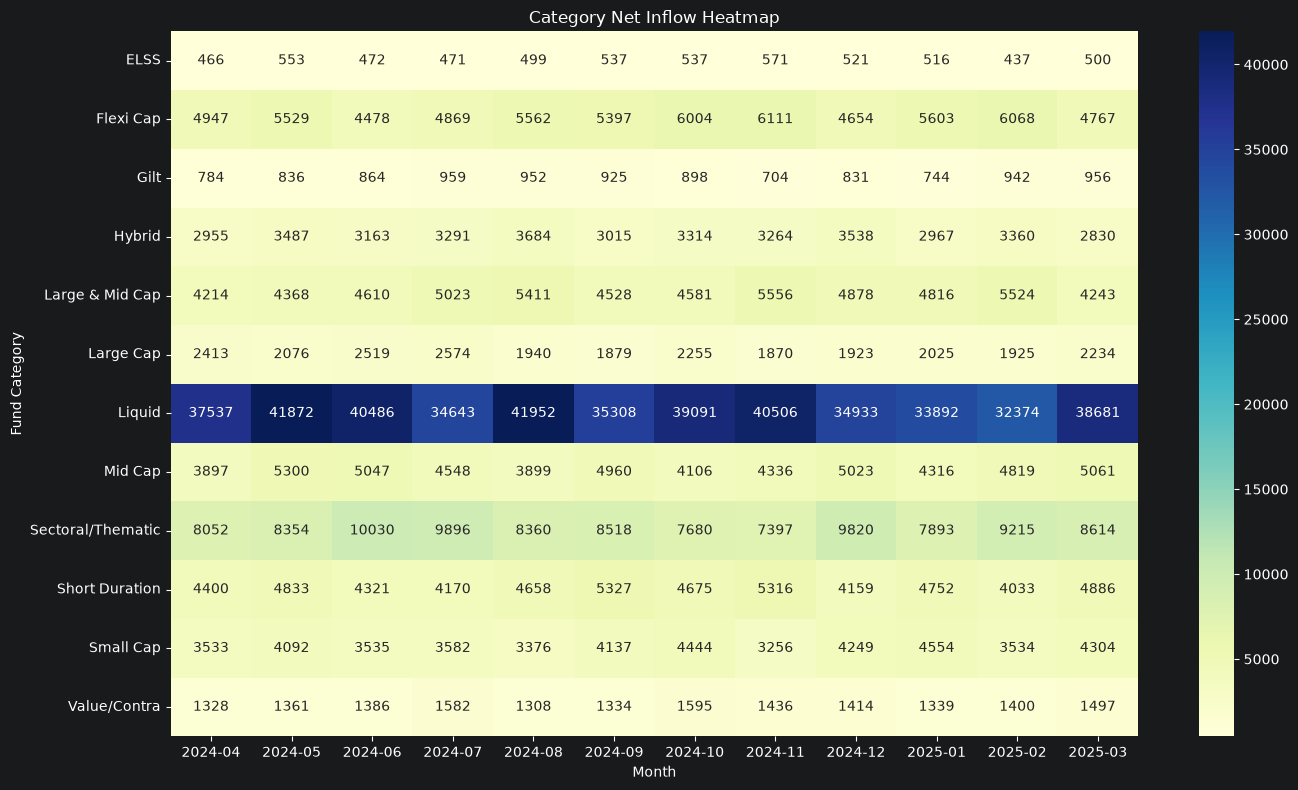

In [33]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [34]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


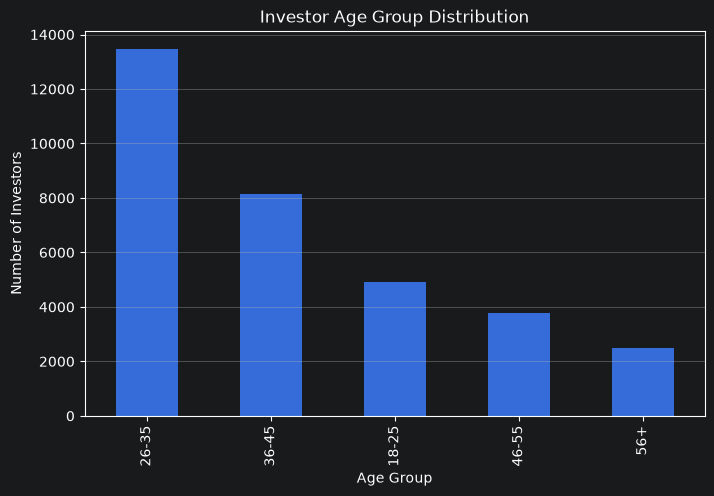

In [35]:
plt.figure(figsize=(8,5))

transactions["age_group"].value_counts().plot(kind="bar")

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")
plt.grid(axis="y")

plt.show()

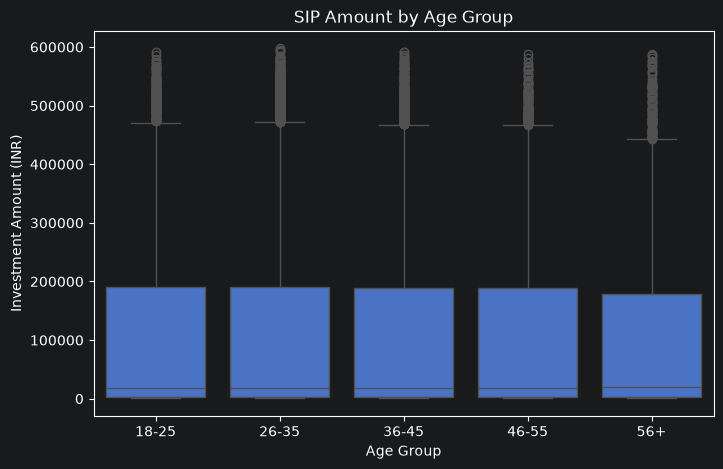

In [40]:
order = ["18-25", "26-35", "36-45", "46-55", "56+"]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr",
    order=order
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

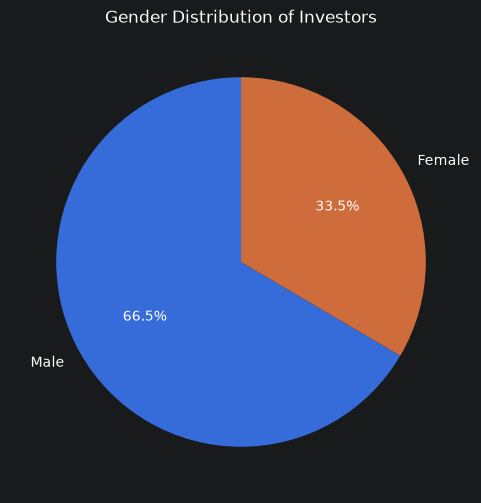

In [39]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.show()

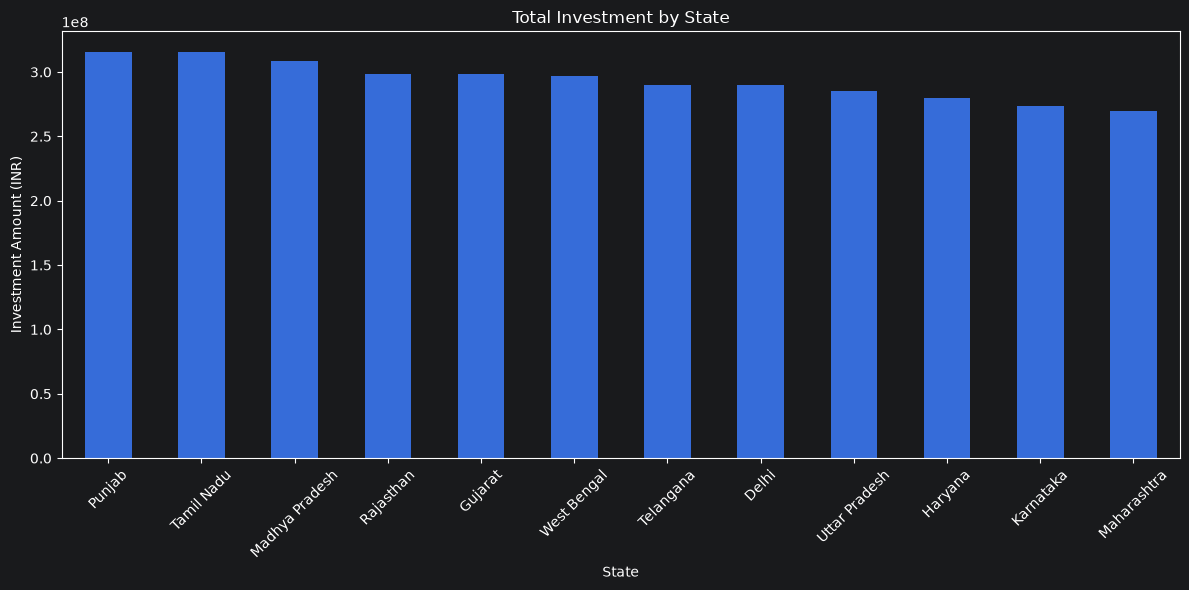

In [41]:
state_amount = transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_amount.plot(kind="bar")

plt.title("Total Investment by State")
plt.xlabel("State")
plt.ylabel("Investment Amount (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

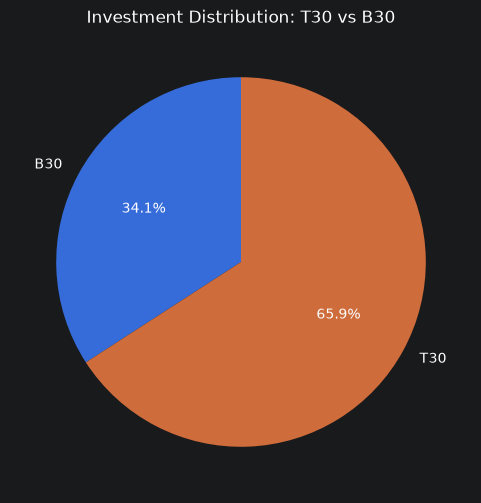

In [42]:
tier_amount = transactions.groupby("city_tier")["amount_inr"].sum()

plt.figure(figsize=(6,6))

plt.pie(
    tier_amount,
    labels=tier_amount.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investment Distribution: T30 vs B30")

plt.show()

In [43]:
transactions["payment_mode"].value_counts()

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

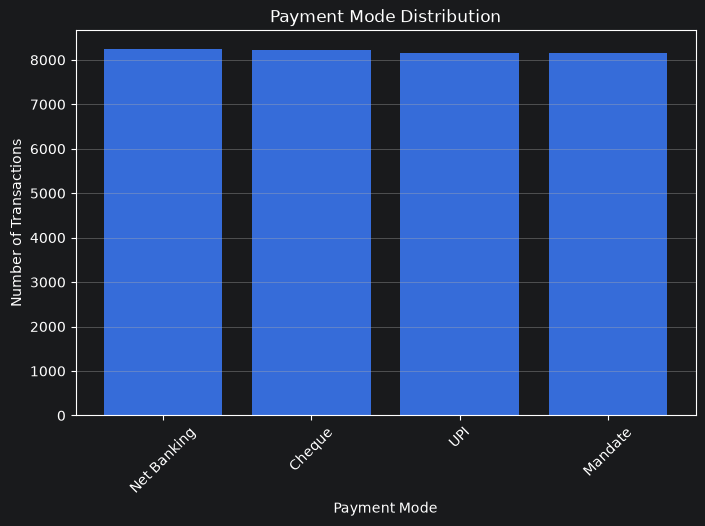

In [44]:
payment = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(payment.index, payment.values)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

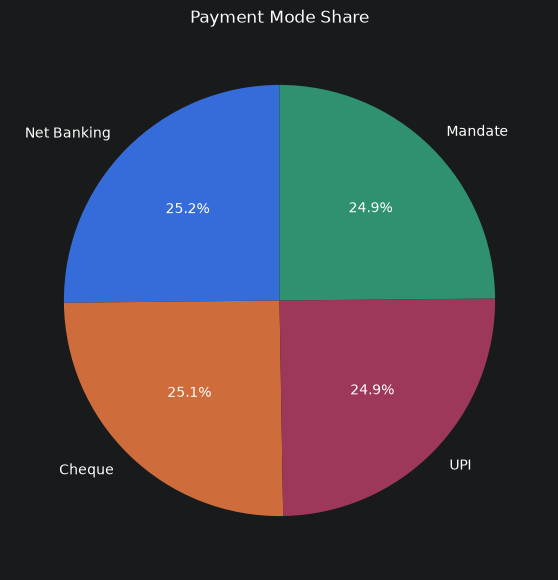

In [45]:
plt.figure(figsize=(7,7))

plt.pie(
    payment.values,
    labels=payment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Mode Share")

plt.show()

In [46]:
transactions["kyc_status"].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

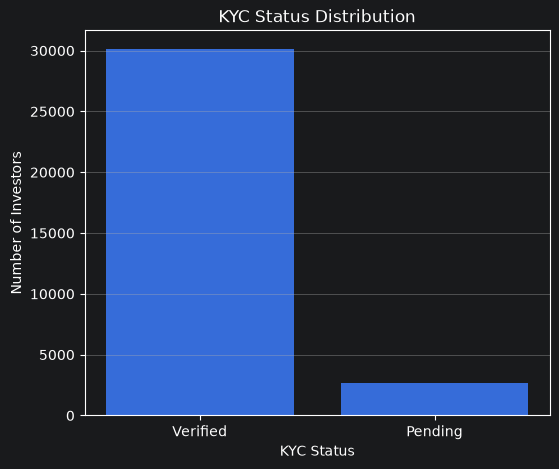

In [47]:
kyc = transactions["kyc_status"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(kyc.index, kyc.values)

plt.title("KYC Status Distribution")
plt.xlabel("KYC Status")
plt.ylabel("Number of Investors")

plt.grid(axis="y")

plt.show()

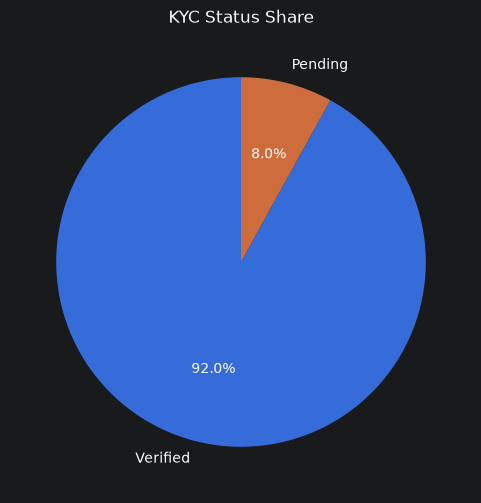

In [48]:
plt.figure(figsize=(6,6))

plt.pie(
    kyc.values,
    labels=kyc.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("KYC Status Share")

plt.show()


# Key Insights

* SBI Mutual Fund has the highest AUM among all fund houses.
* Most fund houses showed steady AUM growth from 2022 to 2025.
* Monthly SIP inflows increased significantly over the analysis period, indicating rising investor participation.
* Liquid funds attracted the highest net inflows among all fund categories.
* Investors aged 26–35 form the largest investor group.
* Male investors account for about two-thirds of the investor base.
* T30 cities contribute a larger share of investments than B30 cities.
* Payment modes are almost evenly distributed across Net Banking, Cheque, UPI, and Mandate.
* Around 92% of investors have completed KYC verification.

## Conclusion

This exploratory data analysis highlights the strong growth of the mutual fund industry between 2022 and 2025. Assets Under Management (AUM) and SIP inflows have consistently increased, indicating growing investor confidence. Young investors (26–35 years) form the largest investor base, while T30 cities contribute the majority of investments. Liquid funds receive the highest inflows, payment modes are well balanced, and around 92% of investors have completed KYC verification. These insights provide a solid understanding of investor behavior and market trends.